# Analysis

In [ ]:
!pip install torch numpy matplotlib seaborn pandas peft

## Analyzing EigCov Covariance Estimator

In [73]:
import sys
import math
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import LinearizedTaskVector, NonLinearTaskVector


MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
SPLIT = "train"
DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
# DATASETS = ["Cars"]
FT_METHODS = ["linear", "standard", "lora"]
K_VALS = [8, 32, 64]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_SAMPLES = 10
MAX_LAYERS = 10

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
# dist_fn = lambda x, x_hat: (torch.linalg.norm(x - x_hat, ord="fro") / torch.linalg.norm(x, ord="fro")).item()
# def dist_fn(A, B, k):
#     """Grassmann chordal distance between top-k eigenspaces of A and B."""
#     _, U_a = torch.linalg.eigh(A.double())
#     _, U_b = torch.linalg.eigh(B.double())
#     k = min(k, U_a.shape[1])
#     U_a = U_a[:, -k:]
#     U_b = U_b[:, -k:]
#     sigmas = torch.linalg.svdvals(U_a.T @ U_b)
#     val = k - (sigmas**2).sum()
#     return torch.sqrt(val.clamp(min=0)).item() / math.sqrt(k)

def dist_fn(A, B, k):
    U_a, _, _ = torch.linalg.svd(A)
    U_b, _, _ = torch.linalg.svd(B)
    k = min(k, U_a.shape[1])
    U_a_k = U_a[:, :k]
    U_b_k = U_b[:, :k]
    sigmas = torch.linalg.svdvals(U_a_k.T @ U_b_k)
    thetas = torch.acos(sigmas.clamp(-1, 1))
    dist = torch.linalg.norm(thetas, ord=2).item()
    normalized_dist = dist / (math.sqrt(k) * torch.pi / 2)  # ∈ [0, 1]
    return normalized_dist

def get_k_for_variance(C, threshold):
    """Get k that explains threshold fraction of variance."""
    eigvals = torch.linalg.eigvalsh(C)
    cumvar = eigvals.flip(0).cumsum(0) / eigvals.sum()
    return (cumvar < threshold).sum().item() + 1

rows = []

TOTAL = len(FT_METHODS) * len(DATASETS)
for idx, (ft_method, dataset) in enumerate(product(FT_METHODS, DATASETS)):
    # Load covariance
    covs = np.load(f"{RESULTS_DIR}/covariances_strain_n{NUM_SAMPLES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

    # Load task vector
    if ft_method == "linear":
        pretrained_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/linear_zeroshot.pt"
        finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/linear_finetuned.pt"
        pretrained_nonlinear_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/zeroshot.pt"

        # Get param names
        nonlinear_encoder = torch.load(
            pretrained_nonlinear_checkpoint, map_location="cpu", weights_only=False
        )
        param_names = [n for n, _ in nonlinear_encoder.named_parameters()]
        del nonlinear_encoder

        tv = LinearizedTaskVector(
            pretrained_checkpoint,
            finetuned_checkpoint,
        )
        encoder = tv.apply_to_nonlinear(
            pretrained_nonlinear_checkpoint, param_names, scaling_coef=1.0
        )
        task_vector = NonLinearTaskVector(
            vector=encoder.state_dict(),
        )
    elif ft_method == "lora":
        pretrained_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/zeroshot.pt"
        finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/lora_finetuned.pt"
        task_vector = NonLinearTaskVector(
            pretrained_checkpoint,
            finetuned_checkpoint,
        )
    else:
        pretrained_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/zeroshot.pt"
        finetuned_checkpoint =  f"{CHECKPOINT_DIR}/{dataset}Val/finetuned.pt"
        task_vector = NonLinearTaskVector(
            pretrained_checkpoint,
            finetuned_checkpoint,
        )

    task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

    # pbar = tqdm(, total=len(task_vector.vector))
    num_added = 0
    for i, (k, m) in enumerate(task_vector.vector.items()):
        kp = param_name_to_module_name(k)
        # print(kp, kp in covs.keys())
        if len(m.shape) != 2 or kp not in covs.keys():
            continue
        # move to device
        m = m.to(DEVICE)
        c = torch.from_numpy(covs[kp]).to(m.dtype).to(DEVICE)
        c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
        c_hat_ec = m.T @ m # EigenCov estimate
        c_hat_zero = torch.zeros_like(c, device=DEVICE)
        for kk in K_VALS:
            for method, c_hat in [("EigenCov", c_hat_ec)]:
                rows.append({
                    "dataset": dataset, "layer_name": k, "layer_idx": i,
                    "method": method, "error": dist_fn(c, c_hat, kk),
                    "k": kk, "ft_method": ft_method,
                })
        print(f"[{idx}/{TOTAL}] -- [{i:2d}/{len(task_vector.vector):2d}] {ft_method} | {dataset} | {k:<{50}s} | M: {str(m.shape):>20s} | C: {str(c.shape):>20s}")
        if MAX_LAYERS is not None and num_added > MAX_LAYERS:
            break
        num_added += 1


# Save
df = pd.DataFrame(rows)
df.to_csv(f"{RESULTS_DIR}/eigcov_estimation_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv", index=False)

0it [00:00, ?it/s]

Loading image encoder from ../checkpoints/ViT-B-16/CarsVal/linear_zeroshot.pt
Loading ViT-B-16 pre-trained weights.
Loading image encoder from ../checkpoints/ViT-B-16/CarsVal/linear_finetuned.pt
Loading ViT-B-16 pre-trained weights.
[linear | Cars] [13/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[linear | Cars] [15/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[linear | Cars] [21/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[linear | Cars] [23/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[linear | Cars] [29/206] model.visual.transformer.resblocks.2.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[linear | Cars] [31/206] model.visual.transformer.resblocks.2.mlp.c_proj.weight | M:

1it [02:17, 137.62s/it]

[linear | Cars] [55/206] model.visual.transformer.resblocks.5.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
Loading image encoder from ../checkpoints/ViT-B-16/DTDVal/linear_zeroshot.pt
Loading ViT-B-16 pre-trained weights.
Loading image encoder from ../checkpoints/ViT-B-16/DTDVal/linear_finetuned.pt
Loading ViT-B-16 pre-trained weights.
[linear | DTD] [13/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[linear | DTD] [15/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[linear | DTD] [21/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[linear | DTD] [23/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[linear | DTD] [29/206] model.visual.transformer.resblocks.2.mlp.c_fc.weight | M: torc

2it [04:36, 138.64s/it]

...

[lora | GTSRB] [55/206] model.visual.transformer.resblocks.5.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | MNIST] [13/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | MNIST] [15/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | MNIST] [21/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | MNIST] [23/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | MNIST] [29/206] model.visual.transformer.resblocks.2.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | MNIST] [31/206] model.visual.transformer.resblocks.2.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | MNIST] [37/206] model.visual.transform

17it [30:23, 56.76s/it]

[lora | MNIST] [55/206] model.visual.transformer.resblocks.5.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | SVHN] [13/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | SVHN] [15/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | SVHN] [21/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | SVHN] [23/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | SVHN] [29/206] model.visual.transformer.resblocks.2.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[lora | SVHN] [31/206] model.visual.transformer.resblocks.2.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[lora | SVHN] [37/206] model.visual.transformer.resb

18it [31:05, 103.62s/it]

[lora | SVHN] [55/206] model.visual.transformer.resblocks.5.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])


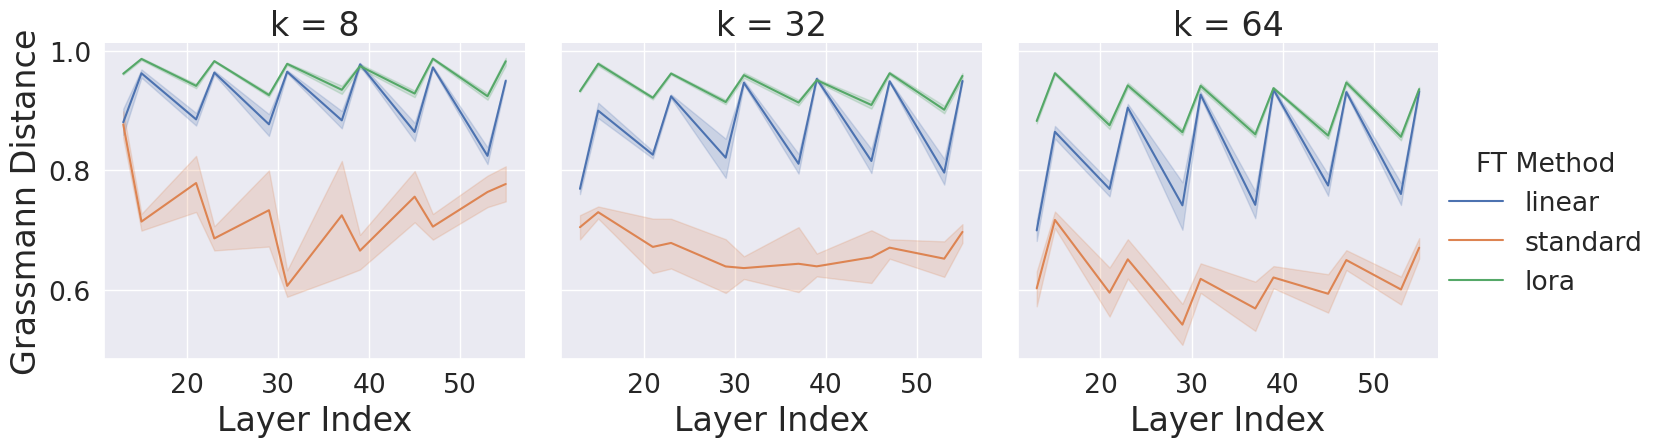

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24
BATCH_SIZE = 32
NUM_SAMPLES = 10

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

# df = pd.read_csv(f"{RESULTS_DIR}/eigcov_estimation_n{NUM_SAMPLES}_b{BATCH_SIZE}.csv")
df = pd.DataFrame(rows)
df = df[df["method"] == "EigenCov"]
df = df[df["k"] <= 128]

# print(df)

g = sns.relplot(
    data=df,
    x="layer_idx",
    y="error",
    hue="ft_method",
    col="k",
    kind="line",
    facet_kws={"sharey": True, "legend_out": True},  # <- goes here
    legend="brief",
)

g.set_axis_labels("Layer Index", "Grassmann Distance")
g.set_titles(col_template="k = {col_name}")

# rename legend title without manual positioning
g.legend.set_title("FT Method")
g.figure.savefig(
    f"{RESULTS_DIR}/eigcov_estimation_line.pdf",
    dpi=300,
    bbox_inches="tight",
)

## Fig. 1: Decorrelation


$ρ(\|a[l-1]\|^2 \;, \|g[l]\|^2)$

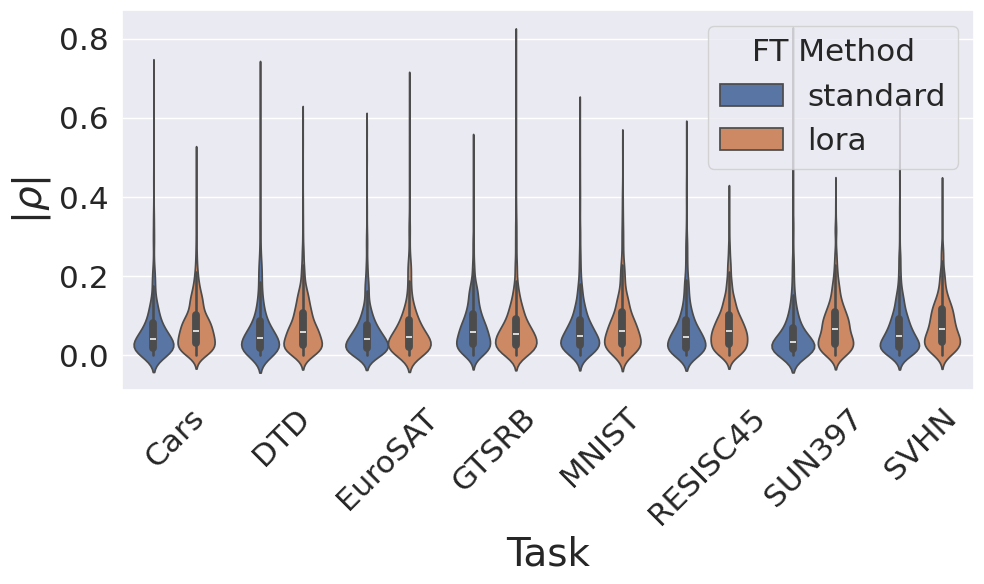


Summary Statistics (all points):
           mean    std    50%    max
task                                
Cars      0.071  0.073  0.051  0.706
DTD       0.072  0.076  0.050  0.700
EuroSAT   0.065  0.075  0.043  0.674
GTSRB     0.073  0.070  0.056  0.788
MNIST     0.076  0.074  0.055  0.616
RESISC45  0.072  0.069  0.054  0.554
SUN397    0.070  0.076  0.047  0.786
SVHN      0.075  0.067  0.057  0.592

Overall mean |ρ|: 0.072
% of all correlations < 0.1: 76.4%


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from itertools import product

sns.set_theme()
BASE_FONTSIZE=28

model = "ViT-B-16"
batch_size = 1
num_samples = 100
num_indices = 32
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ft_methods = ["standard", "lora"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task, ft_method in product(tasks, ft_methods):
    corr_dir = f"../results/{model}/correlations_b{batch_size}_n{num_samples}_k{num_indices}_ft{ft_method}"
    path = f"{corr_dir}/correlation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    # remove "g_sq/" prefix
    layers = [k[5:] for k in data.files if k.startswith("g_sq/")]
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho, 'ft_method': ft_method})

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="task", y="rho", hue="ft_method", ax=ax)

ax.set_xlabel("Task", fontsize=BASE_FONTSIZE)
ax.set_ylabel(r"$|\rho|$", fontsize=BASE_FONTSIZE)
ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8, rotation=45)
ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
ax.legend(title="FT Method", fontsize=BASE_FONTSIZE * 0.8, title_fontsize=BASE_FONTSIZE * 0.8)

plt.tight_layout()
plt.savefig(f"{corr_dir}/correlation_violin.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nSummary Statistics (all points):")
print(df.groupby('task')['rho'].describe()[['mean', 'std', '50%', 'max']].round(3).to_string())
print(f"\nOverall mean |ρ|: {df['rho'].mean():.3f}")
print(f"% of all correlations < 0.1: {(df['rho'] < 0.1).mean() * 100:.1f}%")

In [6]:
# data 
path, os.path.exists(path)

('../results/ViT-B-16/decorrelations_ftlora/decorrelation_SVHN.npz', False)

## Fig. 2 : Accuracy vs. Number of Samples used for Covariance Estimation

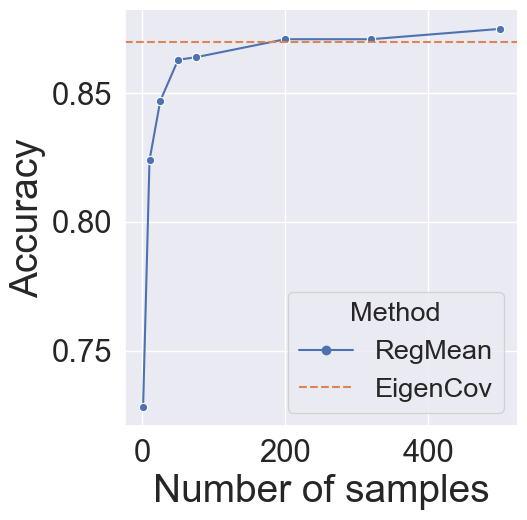

In [ ]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

BASE_FONTSIZE = 28

shared_params = {
    "model": "ViT-B-16",
    "split": "train",
    "cov_type": "sm",
    "estimator": "full",
    "finetune_mode": "full",
    "method": "RegMean",
}

rows = [
    {**shared_params, "n": 1, "acc_abs": 0.728, "acc_rel": 0.772},
    {**shared_params, "n": 10, "acc_abs": 0.824, "acc_rel": 0.871},
    {**shared_params, "n": 25, "acc_abs": 0.847, "acc_rel": 0.895},
    {**shared_params, "n": 50, "acc_abs": 0.863, "acc_rel": 0.911},
    {**shared_params, "n": 75, "acc_abs": 0.864, "acc_rel": 0.913},
    {**shared_params, "n": 320, "acc_abs": 0.871, "acc_rel": 0.918},
    {**shared_params, "n": 200, "acc_abs": 0.871, "acc_rel": 0.919},
    {**shared_params, "n": 500, "acc_abs": 0.875, "acc_rel": 0.923},
]

df = pd.DataFrame(rows)

sns.set_theme()
g = sns.relplot(data=df, x="n", y="acc_abs", hue="method", style="method", kind="line", markers=True)
g.set_ylabels("Accuracy", fontsize=BASE_FONTSIZE)
g.set_xlabels("Number of samples", fontsize=BASE_FONTSIZE)
g.ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8)
g.ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
g.ax.axhline(y=0.87, color=sns.color_palette()[1], linestyle="--", label="EigenCov")
handles, labels = g.ax.get_legend_handles_labels()
g.ax.legend(handles, labels, title="Method", fontsize=BASE_FONTSIZE * 0.7, title_fontsize=BASE_FONTSIZE * 0.7)
g._legend.remove()

# Save as pdf
corr_dir = f"../results"
model = "ViT-B-16"
os.makedirs(corr_dir, exist_ok=True)
plt.savefig(f"{corr_dir}/{model.lower()}_acc_vs_n.pdf", dpi=300, bbox_inches="tight")



## Fig. 4: RegMean vs. EigCov estimation

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
K_VALS = [8, 32, 64]
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for key, m in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(key)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (m.T @ m).float()

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()

            for kk in K_VALS:
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "RegMean", "error": dist_fn(c_rm, c_target, kk)})
                rows.append({"task": task, "layer": key, "n": n, "k": kk, "method": "EigenCov", "error": dist_fn(c_ec, c_target, kk)})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n", "k"])["error"].mean().unstack("method"))


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys

# Add src to path
sys.path.append("..")

from src.vision.task_vectors import NonLinearTaskVector

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
FT_METHOD = "standard"
BATCH_SIZE = 1
N_VALS = [1, 10, 100, 500, 1000]
N_MAX = max(N_VALS)
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")

def frob_error(C, C_target):
    """||C_target - C||_F / ||C_target||_F"""
    diff = torch.linalg.norm(C_target - C, ord="fro")
    norm = torch.linalg.norm(C_target, ord="fro")
    return (diff / norm).item() if norm > 1e-12 else float("nan")

rows = []
for task in tqdm(TASKS, desc="Tasks"):
    # Load target covariance (largest n)
    target_path = f"{RESULTS_DIR}/covariances_strain_n{N_MAX}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
    if not os.path.exists(target_path):
        print(f"Missing target: {target_path}")
        continue
    target_covs = np.load(target_path, allow_pickle=True)

    # Load task vector and compute c_ec = M.T @ M (constant across n)
    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{task}Val/finetuned.pt"
    tv = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)

    layers = [(k, m) for k, m in tv.vector.items() if len(m.shape) == 2 and param_name_to_module_name(k) in target_covs]
    for k, m in tqdm(layers, desc=f"  {task} layers", leave=False):
        kp = param_name_to_module_name(k)
        c_target = torch.from_numpy(target_covs[kp]).float()
        c_ec = (m.T @ m).float()
        ec_err = frob_error(c_ec, c_target)

        for n in N_VALS:
            cov_path = f"{RESULTS_DIR}/covariances_strain_n{n}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft{FT_METHOD}/covariance_{task}.npz"
            if not os.path.exists(cov_path):
                print(f"Missing: {cov_path}")
                continue
            covs = np.load(cov_path, allow_pickle=True)
            if kp not in covs:
                continue
            c_rm = torch.from_numpy(covs[kp]).float()
            rows.append({"task": task, "layer": k, "n": n, "method": "RegMean", "error": frob_error(c_rm, c_target)})
            rows.append({"task": task, "layer": k, "n": n, "method": "EigenCov", "error": ec_err})

df_est = pd.DataFrame(rows)
print(df_est.groupby(["method", "n"])["error"].mean().unstack("method"))


Tasks:   0%|          | 0/8 [00:00<?, ?it/s]

  Cars layers:   0%|          | 0/24 [00:00<?, ?it/s]

  DTD layers:   0%|          | 0/24 [00:00<?, ?it/s]

  EuroSAT layers:   0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
BASE_FONTSIZE = 24

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df_plot = df_est.groupby(["method", "n", "k"])["error"].mean().reset_index()

# EigenCov is constant across n; plot as horizontal dashed line per k facet
palette = {"RegMean": sns.color_palette()[0], "EigenCov": sns.color_palette()[1]}

g = sns.relplot(
    data=df_plot[df_plot["method"] == "RegMean"],
    x="n", y="error",
    col="k",
    kind="line",
    markers=True,
    label="RegMean",
    color=palette["RegMean"],
    facet_kws={"sharey": False, "legend_out": True},
)

# Add EigenCov as a horizontal dashed line per facet
for ax, kk in zip(g.axes.flat, K_VALS):
    ec_err = df_plot[(df_plot["method"] == "EigenCov") & (df_plot["k"] == kk)]["error"].mean()
    ax.axhline(ec_err, linestyle="--", color=palette["EigenCov"], label="EigenCov")
    ax.set_xscale("log")
    ax.set_xticks(N_VALS)
    ax.set_xticklabels(N_VALS, rotation=45)

g.axes.flat[0].legend(title="Method")
g.set_axis_labels("Number of Samples ($n$)", "Grassmann Distance")
g.set_titles(col_template="k = {col_name}")

g.figure.savefig(f"{RESULTS_DIR}/regmean_vs_eigcov_grassmann_vs_n.pdf", dpi=300, bbox_inches="tight")
plt.show()


## Fig. 5: Covariance Stationarity

In [1]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
NUM_BATCHES = 10
BATCH_SIZE = 32
SPLIT = "train"
MAX_CKPT = 25

def frob_error(C, C_ref):
    """||C_ref - C||_F / ||C_ref||_F"""
    norm = np.linalg.norm(C_ref, ord="fro")
    return np.linalg.norm(C_ref - C, ord="fro") / norm if norm > 1e-12 else float("nan")

# ── Discover checkpoint directories ──────────────────────────────────────────
cov_prefix = f"covariances_s{SPLIT}_n{NUM_BATCHES}_b{BATCH_SIZE}_tsm_attnsplit_efull_ft"
ckpt_re = re.compile(rf"{re.escape(cov_prefix)}checkpoint_(\d+)$")

checkpoints = []
for d in os.listdir(RESULTS_DIR):
    m = ckpt_re.match(d)
    if m:
        checkpoints.append((int(m.group(1)), f"checkpoint_{m.group(1)}"))
checkpoints.sort()
print(f"Found {len(checkpoints)} checkpoints: {[c[0] for c in checkpoints]}")

checkpoints = checkpoints[:MAX_CKPT]

final_ckpt_stem = checkpoints[-1][1]
print(f"Reference (C_T): {final_ckpt_stem}")


# ── Discover available datasets from the final checkpoint dir ─────────────────
final_dir = f"{RESULTS_DIR}/{cov_prefix}{final_ckpt_stem}"
dataset_re = re.compile(r"covariance_(.+)\.npz$")
datasets = sorted(
    m.group(1)
    for f in os.listdir(final_dir)
    if (m := dataset_re.match(f))
)
print(f"Found datasets: {datasets}")

# ── Build dataframe ───────────────────────────────────────────────────────────
rows = []
for dataset in tqdm(datasets, desc="Datasets"):
    ref_path = f"{final_dir}/covariance_{dataset}.npz"
    ref_covs = np.load(ref_path, allow_pickle=True)

    for ckpt_num, ckpt_stem in tqdm(checkpoints, desc=dataset, leave=False):
        cov_path = f"{RESULTS_DIR}/{cov_prefix}{ckpt_stem}/covariance_{dataset}.npz"
        if not os.path.exists(cov_path):
            continue
        covs = np.load(cov_path, allow_pickle=True)
        for layer in ref_covs.files:
            if layer not in covs or len(covs[layer].shape) != 2:
                continue
            rows.append({
                "checkpoint": ckpt_num,
                "dataset": dataset,
                "layer": layer,
                "error": frob_error(covs[layer], ref_covs[layer]),
            })

df_ckpt = pd.DataFrame(rows)
df_ckpt.to_csv(f"{RESULTS_DIR}/covariance_stationarity.csv", index=False)
print(f"Saved to {RESULTS_DIR}/covariance_stationarity.csv")
print(df_ckpt.groupby("checkpoint")["error"].mean())


Found 21 checkpoints: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
Reference (C_T): checkpoint_2000
Found datasets: ['Cars', 'DTD', 'EuroSAT', 'GTSRB', 'MNIST', 'SVHN']


Datasets:   0%|          | 0/6 [00:00<?, ?it/s]

Cars:   0%|          | 0/21 [00:00<?, ?it/s]

DTD:   0%|          | 0/21 [00:00<?, ?it/s]

EuroSAT:   0%|          | 0/21 [00:00<?, ?it/s]

GTSRB:   0%|          | 0/21 [00:00<?, ?it/s]

MNIST:   0%|          | 0/21 [00:00<?, ?it/s]

SVHN:   0%|          | 0/21 [00:00<?, ?it/s]

Saved to ../results/ViT-B-16/covariance_stationarity.csv
checkpoint
0       0.754136
100     0.479801
200     0.736075
300     0.438632
400     0.656595
500     0.427924
600     0.575796
700     0.421831
800     0.534210
900     0.372056
1000    0.441143
1100    0.324686
1200    0.368348
1300    0.217404
1400    0.266636
1500    0.117220
1600    0.178654
1700    0.091343
1800    0.119528
1900    0.080436
2000    0.000000
Name: error, dtype: float32


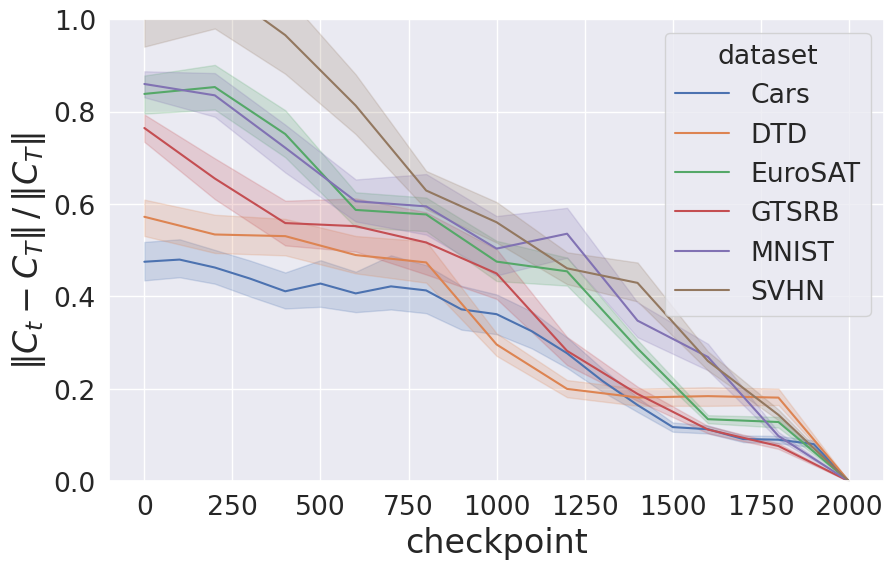

In [2]:
MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"

df_ckpt = pd.read_csv(f"{RESULTS_DIR}/covariance_stationarity.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
BASE_FONTSIZE = 24
sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

# Rename column
error_col = "$\\|C_t - C_T\\| \\,/\\, \\|C_T\\|$"
df_ckpt[error_col] = df_ckpt['error']
df_ckpt = df_ckpt.rename(columns={"error": "Frobenius Error"})

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_ckpt, x="checkpoint", y=error_col, hue="dataset", ax=ax)
ax.set_ylim(0, 1)

plt.show()

## Table 1 & 2. Merging Performance on Standard and LoRA finetuning

In [2]:
import json
import pandas as pd


METRIC = "test_avg_top1"
COLS = ["T5-Base", "T5-Large", "ViT-B/16", "ViT-B/32", "ViT-L/14"]

MODEL_MAP = {
    "t5-base": "T5-Base",
    "t5-large": "T5-Large",
    "T5-Base": "T5-Base",
    "T5-Large": "T5-Large",
    "ViT-B-16": "ViT-B/16",
    "ViT-B-32": "ViT-B/32",
    "ViT-L-14": "ViT-L/14",
}

METHOD_MAP = {
    "mean": "Average",
    "sum": "TA",
    "regmean": "RegMean",
    "eigcov": "EigenCov",
    "tsv": "TSV",
    "isoc_mean": "ISO-C",
    "knots_tsv": "KNOTS-TSV",
    "knots_isoc_mean": "KNOTS-ISO-C",
}

DATA_FREE = {
    "RegMean": True,
    "EigenCov": False,
    "TSV": False,
    "ISO-C": False,
    "KNOTS-TSV": False,
    "KNOTS-ISO-C": False,
}

def get_pivoted_table(ft_mode='lora'):

    with open("../results/results.jsonl", "r") as f:
        df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    with open("../results/results-hpopt.jsonl", "r") as f:
        df = pd.DataFrame(json.loads(line) for line in f if line.strip())

    df = df.copy()
    df["Model"] = df["model"].map(MODEL_MAP).fillna(df["model"])
    df["Method"] = df["merge_func"].map(METHOD_MAP).fillna(df["merge_func"])

    # Filter use only on standard finetuning
    df = df[df['finetuning_mode'] == ft_mode]

    best = df.groupby(["Method", "Model"], as_index=False)[METRIC].max()
    tbl = best.pivot(index="Method", columns="Model", values=METRIC).reindex(columns=COLS)

    # sort by acc on the ViT-B/16 model (descending)
    tbl = tbl.assign(sort_key=tbl["ViT-B/16"]).sort_values("sort_key", ascending=True).drop(columns="sort_key")

    tbl.insert(0, "Data-free", [r"\xmark" if DATA_FREE.get(m, False) else r"\cmark" for m in tbl.index])
    tbl.insert(0, "Method", [rf"\textsc{{{m}}}" for m in tbl.index])

    for c in COLS:
        tbl[c] = tbl[c].map(lambda x: "" if pd.isna(x) else f"{100*x:.1f}")

    return tbl


from IPython.display import display, Markdown
from IPython.display import display, HTML


def print_nice_latex_table(title, tbl):
    display(Markdown(f"### {title}"))
    display(Markdown("```latex\n" + tbl.reset_index(drop=True).to_latex(index=False, escape=False) + "\n```"))

def styled_table(tbl, title):
    styled = tbl.style.set_caption(title).format(precision=1).set_table_styles([
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-weight', 'bold'), ('font-size', '1.1em')]}
    ])  
    display(styled)

# Print latex tables
print_nice_latex_table("Standard", get_pivoted_table(ft_mode='standard'))
print_nice_latex_table("LoRA", get_pivoted_table(ft_mode='lora'))

# # # Print styled tables
# styled_table(get_pivoted_table(ft_mode='standard'), "Standard Finetuning Results")
# display(HTML("<hr style='margin: 2em 0;' />"))
# styled_table(get_pivoted_table(ft_mode='lora'), "LoRA Finetuning Results")


### Standard

```latex
\begin{tabular}{lllllll}
\toprule
Method & Data-free & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\textsc{TA} & \cmark & 71.4 & 69.7 & 76.1 & 69.7 & 84.3 \\
\bottomrule
\end{tabular}

```

### LoRA

```latex
\begin{tabular}{lllllll}
\toprule
Method & Data-free & T5-Base & T5-Large & ViT-B/16 & ViT-B/32 & ViT-L/14 \\
\midrule
\textsc{TA} & \cmark & 71.4 &  & 76.0 & 70.1 & 82.8 \\
\bottomrule
\end{tabular}

```

In [4]:
with open("../results/results-hpopt.jsonl", "r") as f:
    df = pd.DataFrame(json.loads(line) for line in f if line.strip())
df[["model", "merge_func", "finetuning_mode", "test_avg_top1"]]


,model,merge_func,finetuning_mode,test_avg_top1
0,ViT-B-16,sum,standard,0.761121
1,ViT-B-32,sum,standard,0.696859
2,ViT-L-14,sum,standard,0.842962


## Fig. N: Cross-Sample Gradient Orthogonality (Condition i)

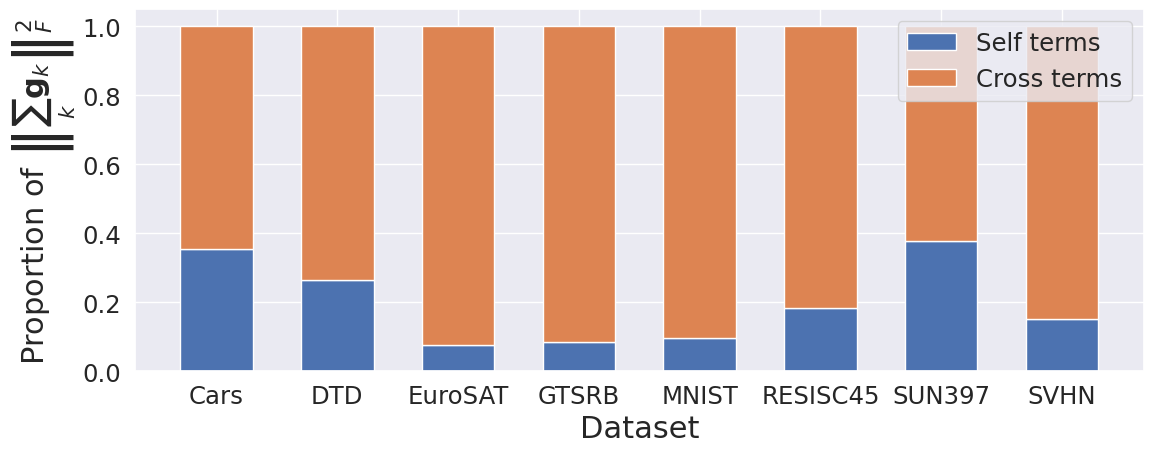

In [33]:
import os
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

MODEL_NAME = "ViT-B-16"
CHECKPOINT_DIR = f"../checkpoints-accum/{MODEL_NAME}"
TASKS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

rows = []
for task in TASKS:
    path = f"{CHECKPOINT_DIR}/{task}Val/grad_cross_ip.pt"
    if not os.path.exists(path):
        print(f"Missing: {path}")
        continue
    data = torch.load(path, map_location="cpu")
    grad_sum = data["grad_sum"]
    grad_sum_sq = grad_sum.dot(grad_sum).item()
    rows.append({
        "dataset": task,
        "self": data["grad_sq_norm_sum"],
        "cross": grad_sum_sq - data["grad_sq_norm_sum"],
        "total": grad_sum_sq,
    })

df = pd.DataFrame(rows)
df["self_prop"] = df["self"] / df["total"]
df["cross_prop"] = df["cross"] / df["total"]

BASE_FONTSIZE = 22
sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
})

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))
width = 0.6
colors = sns.color_palette()

ax.bar(x, df["self_prop"], width, label="Self terms", color=colors[0])
ax.bar(x, df["cross_prop"], width, bottom=df["self_prop"], label="Cross terms", color=colors[1])

ax.set_ylabel(r"Proportion of $\left\|\sum_k \mathbf{g}_k\right\|_F^2$")
ax.set_xlabel("Dataset")
ax.set_xticks(x)
ax.set_xticklabels(df["dataset"])
ax.set_ylim(0, 1.05)
ax.legend(title=None, loc="upper right")
plt.tight_layout()

os.makedirs(f"../results/{MODEL_NAME}", exist_ok=True)
plt.savefig(f"../results/{MODEL_NAME}/grad_cross_ip_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()